In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

In [2]:
hs300 = pd.read_csv("510300etf_tick.csv")

In [3]:
hs300['Unnamed: 0'] = pd.to_datetime(hs300['Unnamed: 0'], format='%Y%m%d%H%M%S')
hs300.rename(columns={'Unnamed: 0': 'datetime'}, inplace=True)
hs300.drop(columns=["time"], inplace=True)

hs300['date'] = hs300['datetime'].dt.strftime("%Y-%m-%d")
hs300['time'] = hs300['datetime'].dt.strftime("%H:%M:%S")
hs300.set_index('datetime', inplace=True)

In [4]:
hs300_morning = hs300.between_time("9:30", "11:30").copy()
hs300_afternoon = hs300.between_time("13:00", "15:00").copy()

In [5]:
hs300_morning['morning'] = 1
hs300_afternoon['morning'] = 0
hs300_filtered = pd.concat([hs300_morning, hs300_afternoon])
hs300_filtered.reset_index(inplace=True)

In [6]:
date_counts = hs300_filtered.groupby('date').size().reset_index(name='count')

In [33]:
n = 5
hs300_filtered['future_return'] = hs300_filtered.groupby('date')['lastPrice'].transform(lambda x: x.shift(-n) / x - 1)
hs300_filtered.dropna(inplace=True, ignore_index=True)
hs300_filtered['label'] = np.sign(hs300_filtered['future_return']).astype(int)
hs300_filtered['label'] = hs300_filtered['label'].replace(-1, 2)
hs300_filtered['label'].value_counts()
hs300_filtered

,datetime,lastPrice,open,high,low,lastClose,amount,volume,pvolume,stockStatus,...,ask_volume_1,bid_volume_1,ask_willingness,bid_willingness,willingness_diff,ask_2,bid_2,ask_volume_2,bid_volume_2,willingness_diff_2
0,2025-01-24 09:30:59,3.895,3.889,3.895,3.883,3.897,6.715817e+07,172655,0,0,...,3069,4795,11953.755,18671.730,-0.000100,3.896,3.893,14975,7720,0.000000
1,2025-01-24 09:31:02,3.895,3.889,3.895,3.883,3.897,6.739144e+07,173254,0,0,...,5724,272,22294.980,1059.168,0.000315,3.896,3.893,12546,7516,-1.496624
2,2025-01-24 09:31:05,3.893,3.889,3.895,3.883,3.897,6.880694e+07,176889,0,0,...,3405,1217,13259.070,4737.781,0.000124,3.895,3.892,6121,8033,0.000000
3,2025-01-24 09:31:08,3.892,3.889,3.895,3.883,3.897,6.986002e+07,179594,0,0,...,2472,7783,9623.496,30291.436,-0.000296,3.894,3.891,862,19991,0.000000
4,2025-01-24 09:31:11,3.892,3.889,3.895,3.883,3.897,7.133885e+07,183393,0,0,...,400,10210,1557.200,39737.320,-0.000535,3.894,3.891,267,13991,20.650389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76339,2025-02-24 14:59:16,4.062,4.070,4.089,4.041,4.075,6.223473e+09,15305204,0,0,...,9038,71041,36712.356,288497.501,-0.000040,4.063,4.060,88936,60672,0.000000
76340,2025-02-24 14:59:19,4.062,4.070,4.089,4.041,4.075,6.227424e+09,15314930,0,0,...,6823,60042,27715.026,243830.562,-0.000035,4.063,4.060,91841,39508,1.730680
76341,2025-02-24 14:59:22,4.063,4.070,4.089,4.041,4.075,6.231117e+09,15324023,0,0,...,89451,240,363439.413,974.880,0.000058,4.064,4.061,25363,59942,0.000000
76342,2025-02-24 14:59:25,4.062,4.070,4.089,4.041,4.075,6.231653e+09,15325341,0,0,...,88156,13351,358177.828,54231.762,0.000049,4.064,4.061,25363,71424,-3.860474


# 因子1：斜率因子

In [8]:
hs300_filtered.loc[:,'askVol'] = hs300_filtered.loc[:,'askVol'].apply(lambda x: eval(x))
hs300_filtered.loc[:,'bidVol'] = hs300_filtered.loc[:,'bidVol'].apply(lambda x: eval(x))
hs300_filtered['askVol1'] = [x[0] for x in hs300_filtered['askVol']]
hs300_filtered['askVol2'] = [x[1] for x in hs300_filtered['askVol']]
hs300_filtered['askVol3'] = [x[2] for x in hs300_filtered['askVol']]
hs300_filtered['askVol4'] = [x[3] for x in hs300_filtered['askVol']]
hs300_filtered['askVol5'] = [x[4] for x in hs300_filtered['askVol']]


hs300_filtered['bidVol1'] = [x[0] for x in hs300_filtered['bidVol']]
hs300_filtered['bidVol2'] = [x[1] for x in hs300_filtered['bidVol']]
hs300_filtered['bidVol3'] = [x[2] for x in hs300_filtered['bidVol']]
hs300_filtered['bidVol4'] = [x[3] for x in hs300_filtered['bidVol']]
hs300_filtered['bidVol5'] = [x[4] for x in hs300_filtered['bidVol']]

In [9]:
Y1 = np.array(hs300_filtered[[
    'askVol1', 'askVol2', 'askVol3', 'askVol4', 'askVol5'
]])
Y2 = np.array(hs300_filtered[[
    'bidVol1', 'bidVol2', 'bidVol3', 'bidVol4', 'bidVol5'
]])

Y1_cumsum = Y1.cumsum(axis=1)
Y2_cumsum = Y2.cumsum(axis=1)
X = np.arange(5).reshape(1, -1)
X = np.tile(X, (Y1.shape[0], 1))
x = X

y1 = np.array([i.reshape(x.shape[1], 1) for i in Y1_cumsum])
y2 = np.array([i.reshape(x.shape[1], 1) for i in Y2_cumsum])

def ols(x, y):
    ones_vector = np.ones((1, x.shape[1]))
    XT = np.stack([np.vstack([ones_vector, row]) for row in x])  #加入常数项
    X = np.array([matrix.T for matrix in XT])  #以行数组表示
    reg_result = np.linalg.pinv(XT @ X) @ XT @ y  #线性回归公示
    return reg_result.reshape(-1, 2)

# hs300_filtered['ask_slope'] = pd.Series(reg_result.reshape(-1, 2)[:, 1])

hs300_filtered['ask_slope'] = ols(x, y1)[:, 1]
hs300_filtered['bid_slope'] = ols(x, y2)[:, 1]

In [10]:
hs300_filtered['slope_factor'] = hs300_filtered['ask_slope'] - hs300_filtered['bid_slope']
hs300_filtered

,datetime,lastPrice,open,high,low,lastClose,amount,volume,pvolume,stockStatus,...,askVol4,askVol5,bidVol1,bidVol2,bidVol3,bidVol4,bidVol5,ask_slope,bid_slope,slope_factor
0,2025-01-24 09:30:02,3.888,3.889,3.889,3.886,3.897,2.510966e+07,64571,0,0,...,1072,6674,21,1381,3121,645,7681,6284.1,2942.2,3341.9
1,2025-01-24 09:30:05,3.888,3.889,3.889,3.883,3.897,3.123802e+07,80339,0,0,...,1075,7174,167,234,215,6788,3275,5633.4,2802.7,2830.7
2,2025-01-24 09:30:08,3.889,3.889,3.891,3.883,3.897,3.829723e+07,98490,0,0,...,900,11086,9080,3660,2046,1573,1725,4358.2,2162.7,2195.5
3,2025-01-24 09:30:11,3.889,3.889,3.891,3.883,3.897,4.384278e+07,112749,0,0,...,926,2867,55,4538,3567,2643,1974,2698.0,3165.4,-467.4
4,2025-01-24 09:30:14,3.890,3.889,3.891,3.883,3.897,4.442973e+07,114258,0,0,...,1326,2967,17,4008,6174,4844,3359,2181.4,4778.8,-2597.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76723,2025-02-24 14:59:31,4.062,4.070,4.089,4.041,4.075,6.246627e+09,15362207,0,0,...,15044,10112,68198,41767,24225,10121,11901,31101.6,21037.4,10064.2
76724,2025-02-24 14:59:34,4.062,4.070,4.089,4.041,4.075,6.246919e+09,15362927,0,0,...,14844,10112,68189,64042,24225,10121,11901,29490.8,25492.4,3998.4
76725,2025-02-24 14:59:37,4.061,4.070,4.089,4.041,4.075,6.247097e+09,15363364,0,0,...,23844,10112,70415,61610,24225,9521,11901,31405.8,24826.0,6579.8
76726,2025-02-24 14:59:40,4.062,4.070,4.089,4.041,4.075,6.251048e+09,15373091,0,0,...,23844,10612,71981,61610,24225,9521,12501,31505.8,24946.0,6559.8


# 因子2：n个tick标准差（论文因子一）

In [11]:
window = 10
hs300_filtered['amount_mean'] = hs300_filtered.groupby('date')['amount'].transform(lambda x: x.rolling(window=window).mean())
hs300_filtered['amount_remove_mean'] = hs300_filtered['amount'] - hs300_filtered['amount_mean']
hs300_filtered['amount_std'] = hs300_filtered.groupby('date')['amount_remove_mean'].transform(lambda x: x.rolling(window=window).std())

# 因子3：成交量差值（论文因子二）

In [12]:
# 按 'date' 分组
grouped = hs300_filtered.groupby('date')

# 定义一个函数，计算每个分组中的移动平均线和差额
def calculate_volume_diff(group, window=10):
    # 计算移动平均线
    group['moving_avg_volume'] = group['volume'].rolling(window=window).mean()
    # 计算差额
    volume_diff = group['volume'] - group['moving_avg_volume']
    return volume_diff

# 对每个分组应用函数
hs300_filtered['volume_diff'] = grouped.apply(calculate_volume_diff).reset_index(level=0, drop=True)

# 因子4：中位数差值（论文因子三）

In [13]:
# 按 date 分组
grouped = hs300_filtered.groupby('date')

# 定义一个函数来计算每个 group 的差值
def calculate_diff(group, window=5):
    # 计算滚动 5 个 tick 的成交量中位数
    rolling_median = group['volume'].rolling(window=window).median()
    
    # 计算开盘至今的成交量中位数
    expanding_median = group['volume'].expanding().median()
    
    # 计算差值
    median_diff = rolling_median - expanding_median
    
    return median_diff

# 对每个 group 应用函数并合并结果
hs300_filtered['median_diff'] = grouped.apply(calculate_diff).reset_index(level=0, drop=True)

# 因子5：成交量偏移（因子四）

In [14]:
def calculate_price1(lst):
    lst = eval(lst)
    # 将列表中的每个元素转换为 float 类型
    lst = [float(x) for x in lst]
    price_1 = lst[0]

    return price_1

hs300_filtered['ask_1'] = hs300_filtered['askPrice'].apply(calculate_price1)
hs300_filtered['bid_1'] = hs300_filtered['bidPrice'].apply(calculate_price1)

In [15]:
hs300_filtered['median_price'] = (hs300_filtered['ask_1'] + hs300_filtered['bid_1']) / 2
hs300_filtered['amount_calc'] = hs300_filtered['median_price'] * hs300_filtered['volume']
hs300_filtered['amount_diff'] = hs300_filtered['amount_calc'] - hs300_filtered['amount']

In [16]:
window = 10
hs300_filtered['amount_mean'] = hs300_filtered.groupby('date')['amount'].transform(lambda x: x.rolling(window=window).mean())
hs300_filtered['amount_diff'] = hs300_filtered['amount_diff'] / hs300_filtered['amount_mean']

# 因子6：移动平均线差额（因子五）

In [17]:
# 按 'date' 分组
grouped = hs300_filtered.groupby('date')

# 定义一个函数，计算每个分组中的移动平均线和差额
def calculate_tick_diff(group, window=20):
    # 计算移动平均线
    group['moving_avg_price'] = group['lastPrice'].rolling(window=window).mean()
    # 计算差额
    price_diff = group['lastPrice'] - group['moving_avg_price']
    return price_diff

# 对每个分组应用函数
hs300_filtered['price_diff'] = grouped.apply(calculate_tick_diff).reset_index(level=0, drop=True)

# 因子7：最高最低价差值（因子六）

In [18]:
window = 20

hs300_filtered = hs300_filtered.groupby('date').apply(
    lambda group: group.assign(
        volatility=group['lastPrice'].rolling(window).max() - group['lastPrice'].rolling(window).min(),
        vwap=(group['lastPrice'] * group['volume']).rolling(window).sum()  / group['volume'].rolling(window).sum(),
        ratio=lambda x: x['volatility'] / x['vwap']
    )
).reset_index(drop=True)

# 因子8：挂单量最大的比值（因子七）

In [19]:

# 应用函数并创建 slope 列
hs300_filtered['ask_volume_max'] = hs300_filtered['askVol'].apply(lambda x: max(x))
hs300_filtered['bid_volume_max'] = hs300_filtered['bidVol'].apply(lambda x: max(x))
hs300_filtered['max_volume_ratio'] = hs300_filtered['ask_volume_max'] / hs300_filtered['bid_volume_max']

# 因子9：相邻tick挂单变化（因子八）

In [20]:

hs300_filtered['ask_volume_sum'] = hs300_filtered['askVol'].apply(lambda x: sum(x))
hs300_filtered['bid_volume_sum'] = hs300_filtered['bidVol'].apply(lambda x: sum(x))
hs300_filtered['volume_sum'] = hs300_filtered['ask_volume_sum'] + hs300_filtered['bid_volume_sum']

In [21]:


hs300_filtered['ask_volume_min'] = hs300_filtered['askVol'].apply(lambda x: min(x))
hs300_filtered['bid_volume_min'] = hs300_filtered['bidVol'].apply(lambda x: min(x))
hs300_filtered['volume_min'] = hs300_filtered[['ask_volume_min', 'bid_volume_min']].min(axis=1)

In [22]:
hs300_filtered['volume_change'] = abs(hs300_filtered['volume_sum'] - hs300_filtered['volume_sum'].shift(1)) / hs300_filtered['volume_min']
hs300_filtered['ask_volume_change'] = abs(hs300_filtered['ask_volume_sum'] - hs300_filtered['ask_volume_sum'].shift(1)) / hs300_filtered['volume_min']
hs300_filtered['bid_volume_change'] = abs(hs300_filtered['bid_volume_sum'] - hs300_filtered['bid_volume_sum'].shift(1)) / hs300_filtered['volume_min']
hs300_filtered['bid_ask_volume_change'] = hs300_filtered['ask_volume_change'] - hs300_filtered['bid_volume_change']

# 因子10：成交意愿（因子九）

In [23]:

hs300_filtered.loc[:,'askPrice'] = hs300_filtered.loc[:,'askPrice'].apply(lambda x: eval(x))
hs300_filtered.loc[:,'bidPrice'] = hs300_filtered.loc[:,'bidPrice'].apply(lambda x: eval(x))

hs300_filtered['ask_1'] = hs300_filtered['askPrice'].apply(lambda x: x[0])
hs300_filtered['bid_1'] = hs300_filtered['bidPrice'].apply(lambda x: x[0])

hs300_filtered['ask_volume_1'] = hs300_filtered['askVol'].apply(lambda x: x[0])
hs300_filtered['bid_volume_1'] = hs300_filtered['bidVol'].apply(lambda x: x[0])

hs300_filtered['ask_willingness'] = hs300_filtered['ask_1'] * hs300_filtered['ask_volume_1']
hs300_filtered['bid_willingness'] = hs300_filtered['bid_1'] * hs300_filtered['bid_volume_1']
hs300_filtered['willingness_diff'] = (hs300_filtered['ask_willingness'] - hs300_filtered['bid_willingness']) / hs300_filtered['amount']

In [194]:
hs300_filtered

,datetime,lastPrice,open,high,low,lastClose,amount,volume,pvolume,stockStatus,...,volume_min,volume_change,ask_volume_change,bid_volume_change,bid_ask_volume_change,ask_volume_1,bid_volume_1,ask_willingness,bid_willingness,willingness_diff
0,2025-01-24 09:30:02,3.888,3.889,3.889,3.886,3.897,2.510966e+07,64571,0,0,...,21,NaN,NaN,NaN,NaN,775,21,3013.200,81.627,0.000117
1,2025-01-24 09:30:05,3.888,3.889,3.889,3.883,3.897,3.123802e+07,80339,0,0,...,167,27.646707,14.652695,12.994012,1.658683,1068,167,4152.384,649.129,0.000112
2,2025-01-24 09:30:08,3.889,3.889,3.891,3.883,3.897,3.829723e+07,98490,0,0,...,197,12.238579,25.350254,37.588832,-12.238579,197,9080,766.527,35312.120,-0.000902
3,2025-01-24 09:30:11,3.889,3.889,3.891,3.883,3.897,4.384278e+07,112749,0,0,...,55,249.163636,152.672727,96.490909,56.181818,144,55,560.304,213.895,0.000008
4,2025-01-24 09:30:14,3.890,3.889,3.891,3.883,3.897,4.442973e+07,114258,0,0,...,17,163.647059,167.235294,330.882353,-163.647059,134,17,521.394,66.130,0.000010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76723,2025-02-24 14:59:31,4.062,4.070,4.089,4.041,4.075,6.246627e+09,15362207,0,0,...,6710,5.709538,2.391356,3.318182,-0.926826,6710,68198,27256.020,276952.078,-0.000040
76724,2025-02-24 14:59:34,4.062,4.070,4.089,4.041,4.075,6.246919e+09,15362927,0,0,...,10112,2.026305,0.175633,2.201938,-2.026305,12888,68189,52351.056,276915.529,-0.000036
76725,2025-02-24 14:59:37,4.061,4.070,4.089,4.041,4.075,6.247097e+09,15363364,0,0,...,9521,0.639744,0.724399,0.084655,0.639744,16162,70415,65650.044,285955.315,-0.000035
76726,2025-02-24 14:59:40,4.062,4.070,4.089,4.041,4.075,6.251048e+09,15373091,0,0,...,7687,0.755691,1.037466,0.281774,0.755691,7687,71981,31224.594,292314.841,-0.000042


# 因子11：二档成交意愿（因子十）

In [24]:
hs300_filtered['ask_2'] = hs300_filtered['askPrice'].apply(lambda x: x[1])
hs300_filtered['bid_2'] = hs300_filtered['bidPrice'].apply(lambda x: x[1])

hs300_filtered['ask_volume_2'] = hs300_filtered['askVol'].apply(lambda x: x[1])
hs300_filtered['bid_volume_2'] = hs300_filtered['bidVol'].apply(lambda x: x[1])
# 首先筛选出买一价和卖一价没有发生变化的数据行
df_filtered = hs300_filtered[(hs300_filtered['ask_1'].shift(1) == hs300_filtered['ask_1']) & 
                             (hs300_filtered['bid_1'].shift(1) == hs300_filtered['bid_1'])].copy()

# 计算买一挂单量的波动
df_filtered['bid_change_1'] = df_filtered['bid_volume_1'].diff()

# 计算卖一挂单量的波动
df_filtered['ask_change_1'] = df_filtered['ask_volume_1'].diff()

# 计算买盘意愿变化程度
df_filtered['bid_willingness_2'] = df_filtered['bid_change_1'] / df_filtered['bid_volume_2']

# 计算卖盘意愿变化程度
df_filtered['ask_willingness_2'] = df_filtered['ask_change_1'] / df_filtered['ask_volume_2']

# 计算因子
df_filtered['willingness_diff_2'] = df_filtered['bid_willingness_2'] - df_filtered['ask_willingness_2']
hs300_filtered = pd.merge(hs300_filtered, df_filtered[['datetime', 'willingness_diff_2']], how='left', on='datetime')
hs300_filtered['willingness_diff_2'] = hs300_filtered['willingness_diff_2'].fillna(0)
hs300_filtered.dropna(inplace=True, ignore_index=True)

# 获取训练集和测试集

In [26]:
latest_date = hs300_filtered['date'].unique().max()

training_set = hs300_filtered[hs300_filtered['date'] < latest_date].copy()
testing_set = hs300_filtered[hs300_filtered['date'] == latest_date].copy()

factors = ["slope_factor", "amount_std", "volume_diff", "median_diff", "amount_diff", "price_diff", "ratio", "max_volume_ratio",
           "volume_change", "willingness_diff", "willingness_diff_2",  "ask_volume_change", "bid_volume_change", "bid_ask_volume_change",
           ]


X_train = training_set[factors].copy()
y_train = training_set["label"].copy()
X_test = testing_set[factors].copy()
y_test = testing_set["label"].copy()

# lightgbm

In [27]:
import lightgbm as lgb

params = {
    'objective': 'multiclass',  # 多分类任务
    'num_class': 3,             # 类别数
    'metric': 'multiclass',     # 评估指标
    'boosting_type': 'gbdt',    # 提升类型
    'num_leaves': 31,           # 叶子节点数
    'learning_rate': 0.05,      # 学习率
    'feature_fraction': 0.9,    # 特征采样比例
    'bagging_fraction': 0.8,    # 数据采样比例
    'bagging_freq': 5,          # 每5次迭代进行一次bagging
    'verbose': 0,               # 是否打印训练过程
    'num_threads': 6,           # 线程数
}

# 创建 LightGBM 数据集
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# 训练模型
num_round = 500
bst = lgb.train(params, train_data, num_round, valid_sets=[test_data])

# 预测
y_pred = bst.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)  # 取概率最大的类别作为预测结果

# 评估结果

In [28]:
print(np.unique(y_test, return_counts=True))
print(np.unique(y_pred, return_counts=True))

(array([0, 1, 2]), array([1878, 1484, 1414], dtype=int64))
(array([0, 1, 2], dtype=int64), array([3013,  790,  973], dtype=int64))


In [32]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

precision = precision_score(y_test, y_pred, average=None)
print(f"Precision: {precision}")

recall = recall_score(y_test, y_pred, average=None)
print(f"Recall: {recall}")

f1 = f1_score(y_test, y_pred, average=None)
print(f"F1-Score: {f1}")

conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{conf_matrix}")

report = classification_report(y_test, y_pred)
print(f"Classification Report:\n{report}")

Accuracy: 0.42273869346733667
Precision: [0.41387322 0.46075949 0.41932169]
Recall: [0.66400426 0.24528302 0.28854314]
F1-Score: [0.50991617 0.32014072 0.3418517 ]
Confusion Matrix:
[[1247  276  355]
 [ 910  364  210]
 [ 856  150  408]]
Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.66      0.51      1878
           1       0.46      0.25      0.32      1484
           2       0.42      0.29      0.34      1414

    accuracy                           0.42      4776
   macro avg       0.43      0.40      0.39      4776
weighted avg       0.43      0.42      0.40      4776



<Axes: >

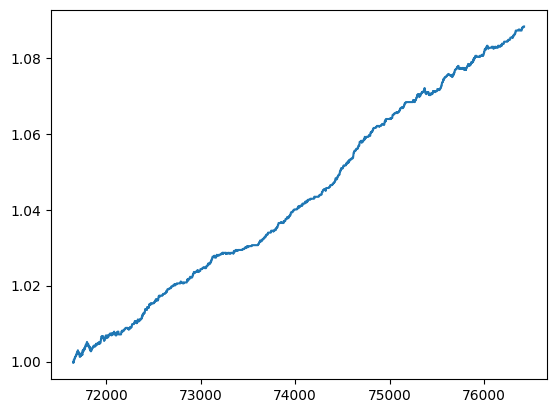

In [30]:
testing_set['y_pred'] = y_pred
testing_set['y_pred'] = testing_set['y_pred'].replace(2, -1)
get = testing_set.y_pred#.apply(lambda x: 1 if x > 0 else 0)
net = (get.shift(1) * testing_set.lastPrice.pct_change() + 1).apply(lambda x: x  if x != 0 else 0)
net.cumprod().plot()

In [209]:
testing_set.y_pred > 0

71648     True
71649    False
71650    False
71651    False
71652    False
         ...  
76419    False
76420     True
76421    False
76422    False
76423    False
Name: y_pred, Length: 4776, dtype: bool